# 🎓 University Academic Data Warehouse — Polynomial Regression Analysis
**Business Intelligence | Group 2**

Members: Max Murage, Christine Wambui, Johnson Mwauza, Ambreen Watetu, Yvonne Nzioka,
Kepha Weru, Abdikheir Adan, David Ouma, Kungu Ian, Brian Kimanzi, Hailey Wanjiru

---

## Instructions
1. Upload **`university_data_warehouse.csv`** to this Colab session:
   - Click the 📁 folder icon on the left sidebar → click the upload (⬆) button → select the CSV
2. Then click **Runtime → Run all**

This notebook reads the real CSV dataset and runs **Polynomial Regression (Degree 2, 3, and 4)**
across four analytical domains:

| # | Domain | Target Variable |
|---|--------|----------------|
| 1 | Student Performance Trends | Average GPA per semester |
| 2 | Enrollment Patterns | Number of students enrolled per year |
| 3 | Graduation Rates | % of students graduating per department |
| 4 | Course Demand | Number of registrations per course |


## Cell 1 — Import Libraries

In [1]:
# All libraries are pre-installed in Google Colab — nothing to pip install.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")
np.random.seed(42)

print("✔ Libraries loaded.")


✔ Libraries loaded.


## Cell 2 — Load the Dataset
Reads `university_data_warehouse.csv` from the Colab file system.

In [2]:
# Load the uploaded CSV file.
# If you get a FileNotFoundError, make sure you uploaded the CSV via the
# left sidebar (folder icon → upload button) before running this cell.

df = pd.read_csv("university_data_warehouse.csv")

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: 200 rows × 18 columns

Column names:
['Student_ID', 'Gender', 'Department', 'Program', 'Year_of_Study', 'Semester', 'Enrollment_Year', 'Entry_Qualification', 'Entry_Score', 'GPA', 'Units_Registered', 'Units_Passed', 'Units_Failed', 'Attendance_Rate_%', 'Tuition_Status', 'Scholarship', 'Course_Registered', 'Graduated']

First 5 rows:


,Student_ID,Gender,Department,Program,Year_of_Study,Semester,Enrollment_Year,Entry_Qualification,Entry_Score,GPA,Units_Registered,Units_Passed,Units_Failed,Attendance_Rate_%,Tuition_Status,Scholarship,Course_Registered,Graduated
0,SCT221-0001/2022,Female,Medicine,MBChB,2,1,2022,KCSE B,68,2.98,16,15,1,90.9,Fully Paid,No,Research Methods,No
1,SCT221-0002/2022,Male,Education,BEd Science,3,2,2021,KCSE B+,73,3.40,14,13,1,75.4,Partially Paid,No,Introduction to Programming,No
2,SCT221-0003/2022,Male,Engineering,BSc Civil Engineering,3,2,2021,KCSE B+,73,3.09,12,12,0,79.2,Unpaid,No,Anatomy I,No
3,SCT221-0004/2022,Female,Education,BEd Science,4,1,2020,KCSE B+,76,3.76,12,10,2,67.7,HELB Loan,No,Anatomy I,No
4,SCT221-0005/2022,Male,Education,BEd Arts,4,2,2020,KCSE B+,76,3.38,15,15,0,65.2,Scholarship,Yes,Research Methods,Yes


## Cell 3 — Exploratory Data Analysis (EDA)
Quick overview of the data before modelling.

In [3]:
# Basic statistics for numerical columns
print("=== Basic Statistics ===")
print(df.describe().round(2).to_string())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Department Distribution ===")
print(df['Department'].value_counts())

print("\n=== Graduation Count ===")
print(df['Graduated'].value_counts())


=== Basic Statistics ===
       Year_of_Study  Semester  Enrollment_Year  Entry_Score     GPA  Units_Registered  Units_Passed  Units_Failed  Attendance_Rate_%
count         200.00    200.00           200.00       200.00  200.00            200.00        200.00        200.00             200.00
mean            2.38      1.48          2021.62        73.54    3.22             15.04         14.12          0.92              77.25
std             1.11      0.50             1.11         5.67    0.25              2.02          2.24          0.80               9.81
min             1.00      1.00          2020.00        61.00    2.65             12.00         10.00          0.00              49.10
25%             1.00      1.00          2021.00        70.00    3.05             13.00         12.75          0.00              70.65
50%             2.00      1.00          2022.00        73.00    3.21             15.00         14.00          1.00              77.55
75%             3.00      2.00       

## Cell 4 — Aggregate Data for Each Analytical Domain
We aggregate (group) the raw student-level data into the four domains we want to model:
1. **Average GPA per semester** (per year × semester combination)
2. **Enrollment count per year**
3. **Graduation rate per department**
4. **Registration count per course**


In [4]:
# ── DOMAIN 1: Student Performance — Average GPA per (Year, Semester) ──────────
# Create a unique semester index: Year 1 Sem 1 = 1, Year 1 Sem 2 = 2, etc.
df["Semester_Index"] = (df["Year_of_Study"] - 1) * 2 + df["Semester"]

perf = (df.groupby("Semester_Index")["GPA"]
          .mean()
          .reset_index()
          .sort_values("Semester_Index"))
perf.columns = ["Semester_Index", "Avg_GPA"]

print("Domain 1 — Student Performance (GPA by Semester Index):")
print(perf.to_string(index=False))

# ── DOMAIN 2: Enrollment — Students enrolled per year ─────────────────────────
enroll = (df.groupby("Enrollment_Year")["Student_ID"]
            .count()
            .reset_index()
            .sort_values("Enrollment_Year"))
enroll.columns = ["Enrollment_Year", "Student_Count"]
# Create a numeric year index starting at 1
enroll["Year_Index"] = range(1, len(enroll) + 1)

print("\nDomain 2 — Enrollment Patterns:")
print(enroll.to_string(index=False))

# ── DOMAIN 3: Graduation Rate — % graduated per department ────────────────────
grad = df.groupby("Department").apply(
    lambda g: round(100 * (g["Graduated"] == "Yes").sum() / len(g), 2)
).reset_index()
grad.columns = ["Department", "Graduation_Rate_%"]
grad["Dept_Index"] = range(1, len(grad) + 1)

print("\nDomain 3 — Graduation Rates by Department:")
print(grad.to_string(index=False))

# ── DOMAIN 4: Course Demand — Registrations per course ───────────────────────
course = (df.groupby("Course_Registered")["Student_ID"]
            .count()
            .reset_index()
            .sort_values("Student_ID", ascending=False))
course.columns = ["Course", "Registrations"]
course["Course_Index"] = range(1, len(course) + 1)

print("\nDomain 4 — Course Demand:")
print(course.to_string(index=False))


Domain 1 — Student Performance (GPA by Semester Index):
 Semester_Index  Avg_GPA
              1 3.106286
              2 3.092273
              3 3.263077
              4 3.227200
              5 3.214783
              6 3.243214
              7 3.366190
              8 3.315500

Domain 2 — Enrollment Patterns:
 Enrollment_Year  Student_Count  Year_Index
            2020             41           1
            2021             51           2
            2022             51           3
            2023             57           4

Domain 3 — Graduation Rates by Department:
      Department  Graduation_Rate_%  Dept_Index
        Business              27.59           1
Computer Science              12.12           2
       Education               9.38           3
     Engineering              18.75           4
             Law               9.38           5
        Medicine              19.05           6

Domain 4 — Course Demand:
                     Course  Registrations  Course_Index
  

## Cell 5 — Helper Functions for Modelling & Plotting

In [5]:
def build_poly_model(degree):
    """
    Builds a scikit-learn Pipeline:
      Step 1 → PolynomialFeatures: converts x into [1, x, x², ..., x^degree]
      Step 2 → LinearRegression:  fits coefficients on those expanded features
    Using a Pipeline keeps both steps together so .fit() / .predict() work cleanly.
    """
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=True)),
        ("lr",   LinearRegression())
    ])


def fit_and_evaluate(X_flat, y, degrees=[2, 3, 4]):
    """
    Trains polynomial models of each degree on (X, y) and returns a dict:
      { degree: (r2, rmse, y_pred) }
    
    r2   → R² score: how much variance the model explains (1.0 = perfect)
    rmse → Root Mean Squared Error: average error in y's original units
    """
    X = X_flat.reshape(-1, 1).astype(float)
    results = {}
    for d in degrees:
        model = build_poly_model(d)
        model.fit(X, y)
        y_pred = model.predict(X)
        r2   = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        results[d] = (r2, rmse, y_pred, model)
    return results


def plot_domain(ax, X_flat, y, results, title, xlabel, ylabel, x_ticks=None, x_tick_labels=None):
    """
    Plots actual data (blue dots) + fitted polynomial curves for degrees 2, 3, 4.
    R² is shown in the legend for each degree.
    """
    colors = {2: "#e74c3c", 3: "#2ecc71", 4: "#9b59b6"}
    names  = {2: "Degree 2 (Quadratic)", 3: "Degree 3 (Cubic)", 4: "Degree 4 (Quartic)"}

    ax.scatter(X_flat, y, color="#3498db", s=70, zorder=5,
               edgecolors="white", linewidth=0.8, label="Actual Data")

    x_smooth = np.linspace(X_flat.min(), X_flat.max(), 300).reshape(-1, 1)
    for d, (r2, rmse, _, model) in results.items():
        y_smooth = model.predict(x_smooth)
        ax.plot(x_smooth, y_smooth, color=colors[d], linewidth=2.2,
                label=f"{names[d]}  |  R²={r2:.4f}")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels, rotation=30, ha="right", fontsize=7)


def print_table(domain_name, results):
    """Prints a clean results table for one domain."""
    names = {2: "Quadratic", 3: "Cubic", 4: "Quartic"}
    print(f"\n{'─'*55}")
    print(f"  {domain_name}")
    print(f"{'─'*55}")
    print(f"  {'Degree':<8} {'Model':<14} {'R²':>8} {'RMSE':>10}")
    print(f"  {'-'*8} {'-'*14} {'-'*8} {'-'*10}")
    for d, (r2, rmse, _, _m) in results.items():
        print(f"  {d:<8} {names[d]:<14} {r2:>8.4f} {rmse:>10.4f}")
    best = max(results, key=lambda d: results[d][0])
    print(f"  → Best: Degree {best} ({names[best]})  R²={results[best][0]:.4f}")

print("✔ Helper functions ready.")


✔ Helper functions ready.


## Cell 6 — Fit Polynomial Regression Models
Degree 2, 3, and 4 for all four domains.

In [6]:
# Domain 1 — GPA
X1 = perf["Semester_Index"].values
y1 = perf["Avg_GPA"].values
res1 = fit_and_evaluate(X1, y1)
print_table("1. Student Performance (Avg GPA per Semester)", res1)

# Domain 2 — Enrollment
X2 = enroll["Year_Index"].values
y2 = enroll["Student_Count"].values.astype(float)
res2 = fit_and_evaluate(X2, y2)
print_table("2. Enrollment Patterns (Students per Year)", res2)

# Domain 3 — Graduation Rate
X3 = grad["Dept_Index"].values
y3 = grad["Graduation_Rate_%"].values
res3 = fit_and_evaluate(X3, y3)
print_table("3. Graduation Rate % by Department", res3)

# Domain 4 — Course Demand
X4 = course["Course_Index"].values
y4 = course["Registrations"].values.astype(float)
res4 = fit_and_evaluate(X4, y4)
print_table("4. Course Demand (Registrations per Course)", res4)

print("\n✔ All models fitted.")



───────────────────────────────────────────────────────
  1. Student Performance (Avg GPA per Semester)
───────────────────────────────────────────────────────
  Degree   Model                R²       RMSE
  -------- -------------- -------- ----------
  2        Quadratic        0.7467     0.0442
  3        Cubic            0.7512     0.0438
  4        Quartic          0.7591     0.0431
  → Best: Degree 4 (Quartic)  R²=0.7591

───────────────────────────────────────────────────────
  2. Enrollment Patterns (Students per Year)
───────────────────────────────────────────────────────
  Degree   Model                R²       RMSE
  -------- -------------- -------- ----------
  2        Quadratic        0.9030     1.7889
  3        Cubic            1.0000     0.0000
  4        Quartic          1.0000     0.0000
  → Best: Degree 3 (Cubic)  R²=1.0000

───────────────────────────────────────────────────────
  3. Graduation Rate % by Department
─────────────────────────────────────────────────

## Cell 7 — Comparison Charts (Degree 2 vs 3 vs 4)

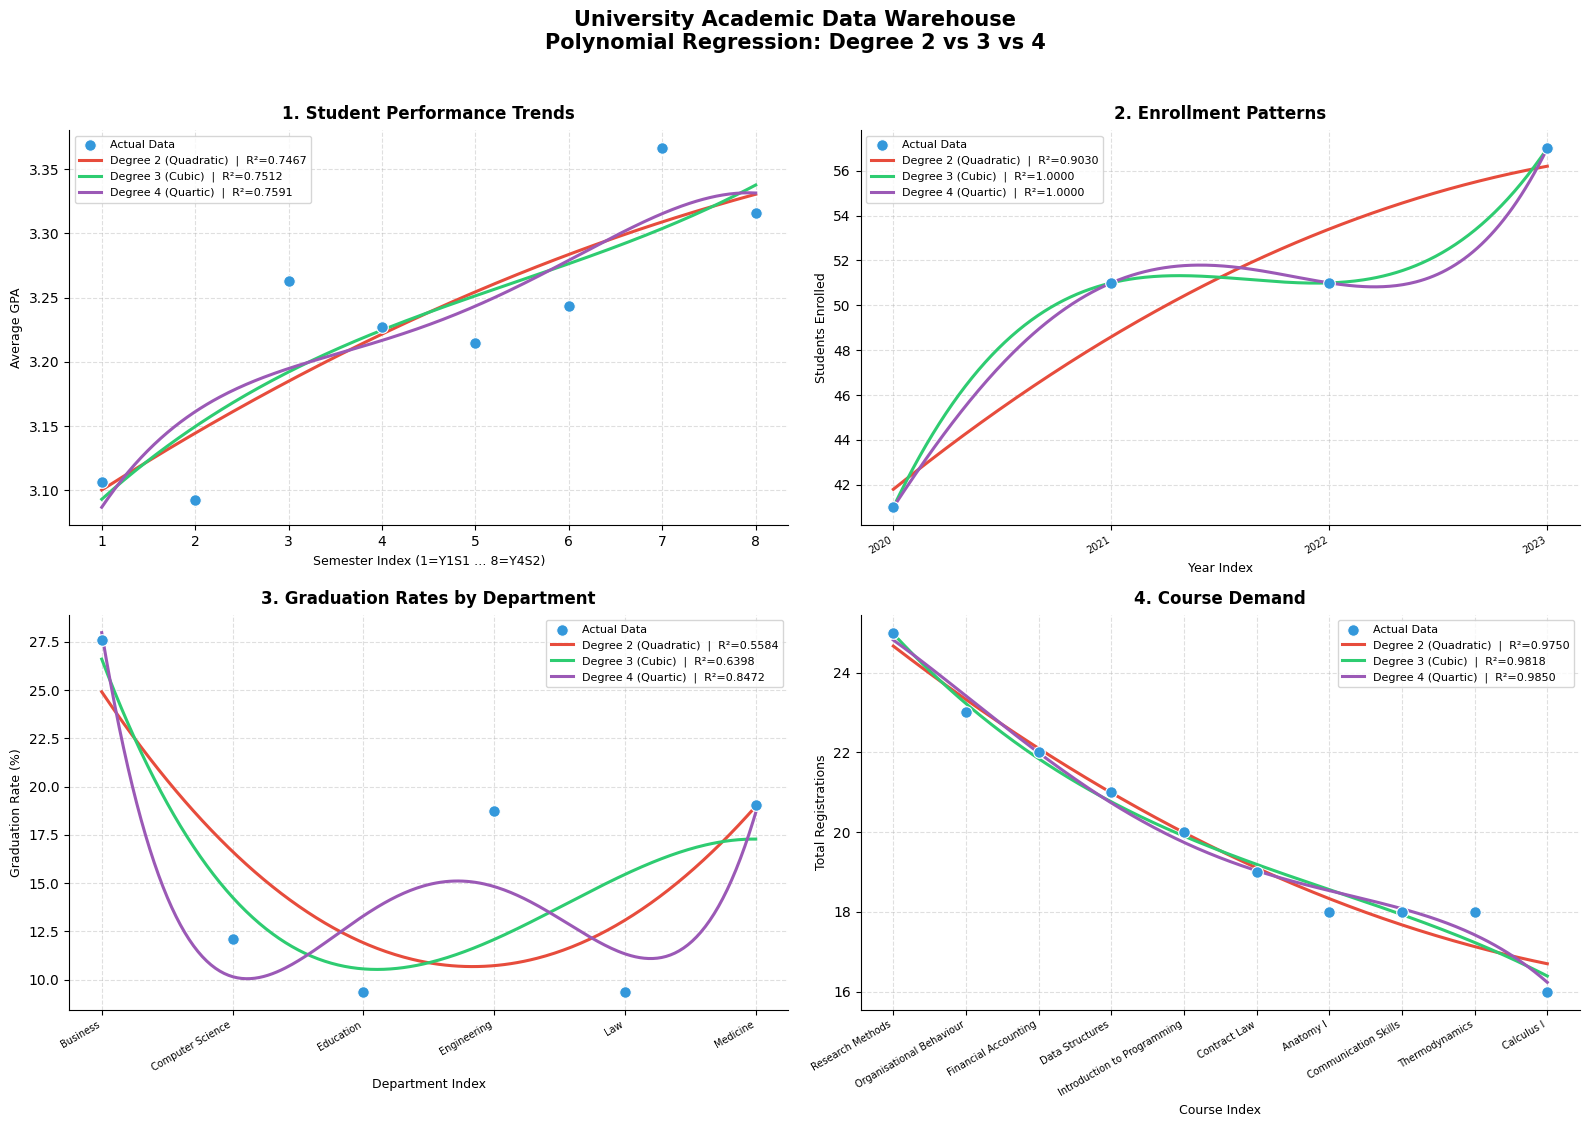

✔ Chart saved as 'polynomial_regression_comparison.png'


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "University Academic Data Warehouse\nPolynomial Regression: Degree 2 vs 3 vs 4",
    fontsize=15, fontweight="bold", y=1.02
)

# Plot 1 — Student Performance
plot_domain(axes[0,0], X1, y1, res1,
            "1. Student Performance Trends",
            "Semester Index (1=Y1S1 … 8=Y4S2)", "Average GPA")

# Plot 2 — Enrollment
plot_domain(axes[0,1], X2, y2, res2,
            "2. Enrollment Patterns",
            "Year Index", "Students Enrolled",
            x_ticks=enroll["Year_Index"].values,
            x_tick_labels=enroll["Enrollment_Year"].values)

# Plot 3 — Graduation Rate
plot_domain(axes[1,0], X3, y3, res3,
            "3. Graduation Rates by Department",
            "Department Index", "Graduation Rate (%)",
            x_ticks=grad["Dept_Index"].values,
            x_tick_labels=grad["Department"].values)

# Plot 4 — Course Demand
plot_domain(axes[1,1], X4, y4, res4,
            "4. Course Demand",
            "Course Index", "Total Registrations",
            x_ticks=course["Course_Index"].values,
            x_tick_labels=course["Course"].values)

plt.tight_layout()
plt.savefig("polynomial_regression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Chart saved as 'polynomial_regression_comparison.png'")


## Cell 8 — Residuals Analysis
**Residual = Actual − Predicted**

Points should be scattered randomly around the dashed zero line.
A curved pattern means the model is still underfitting.

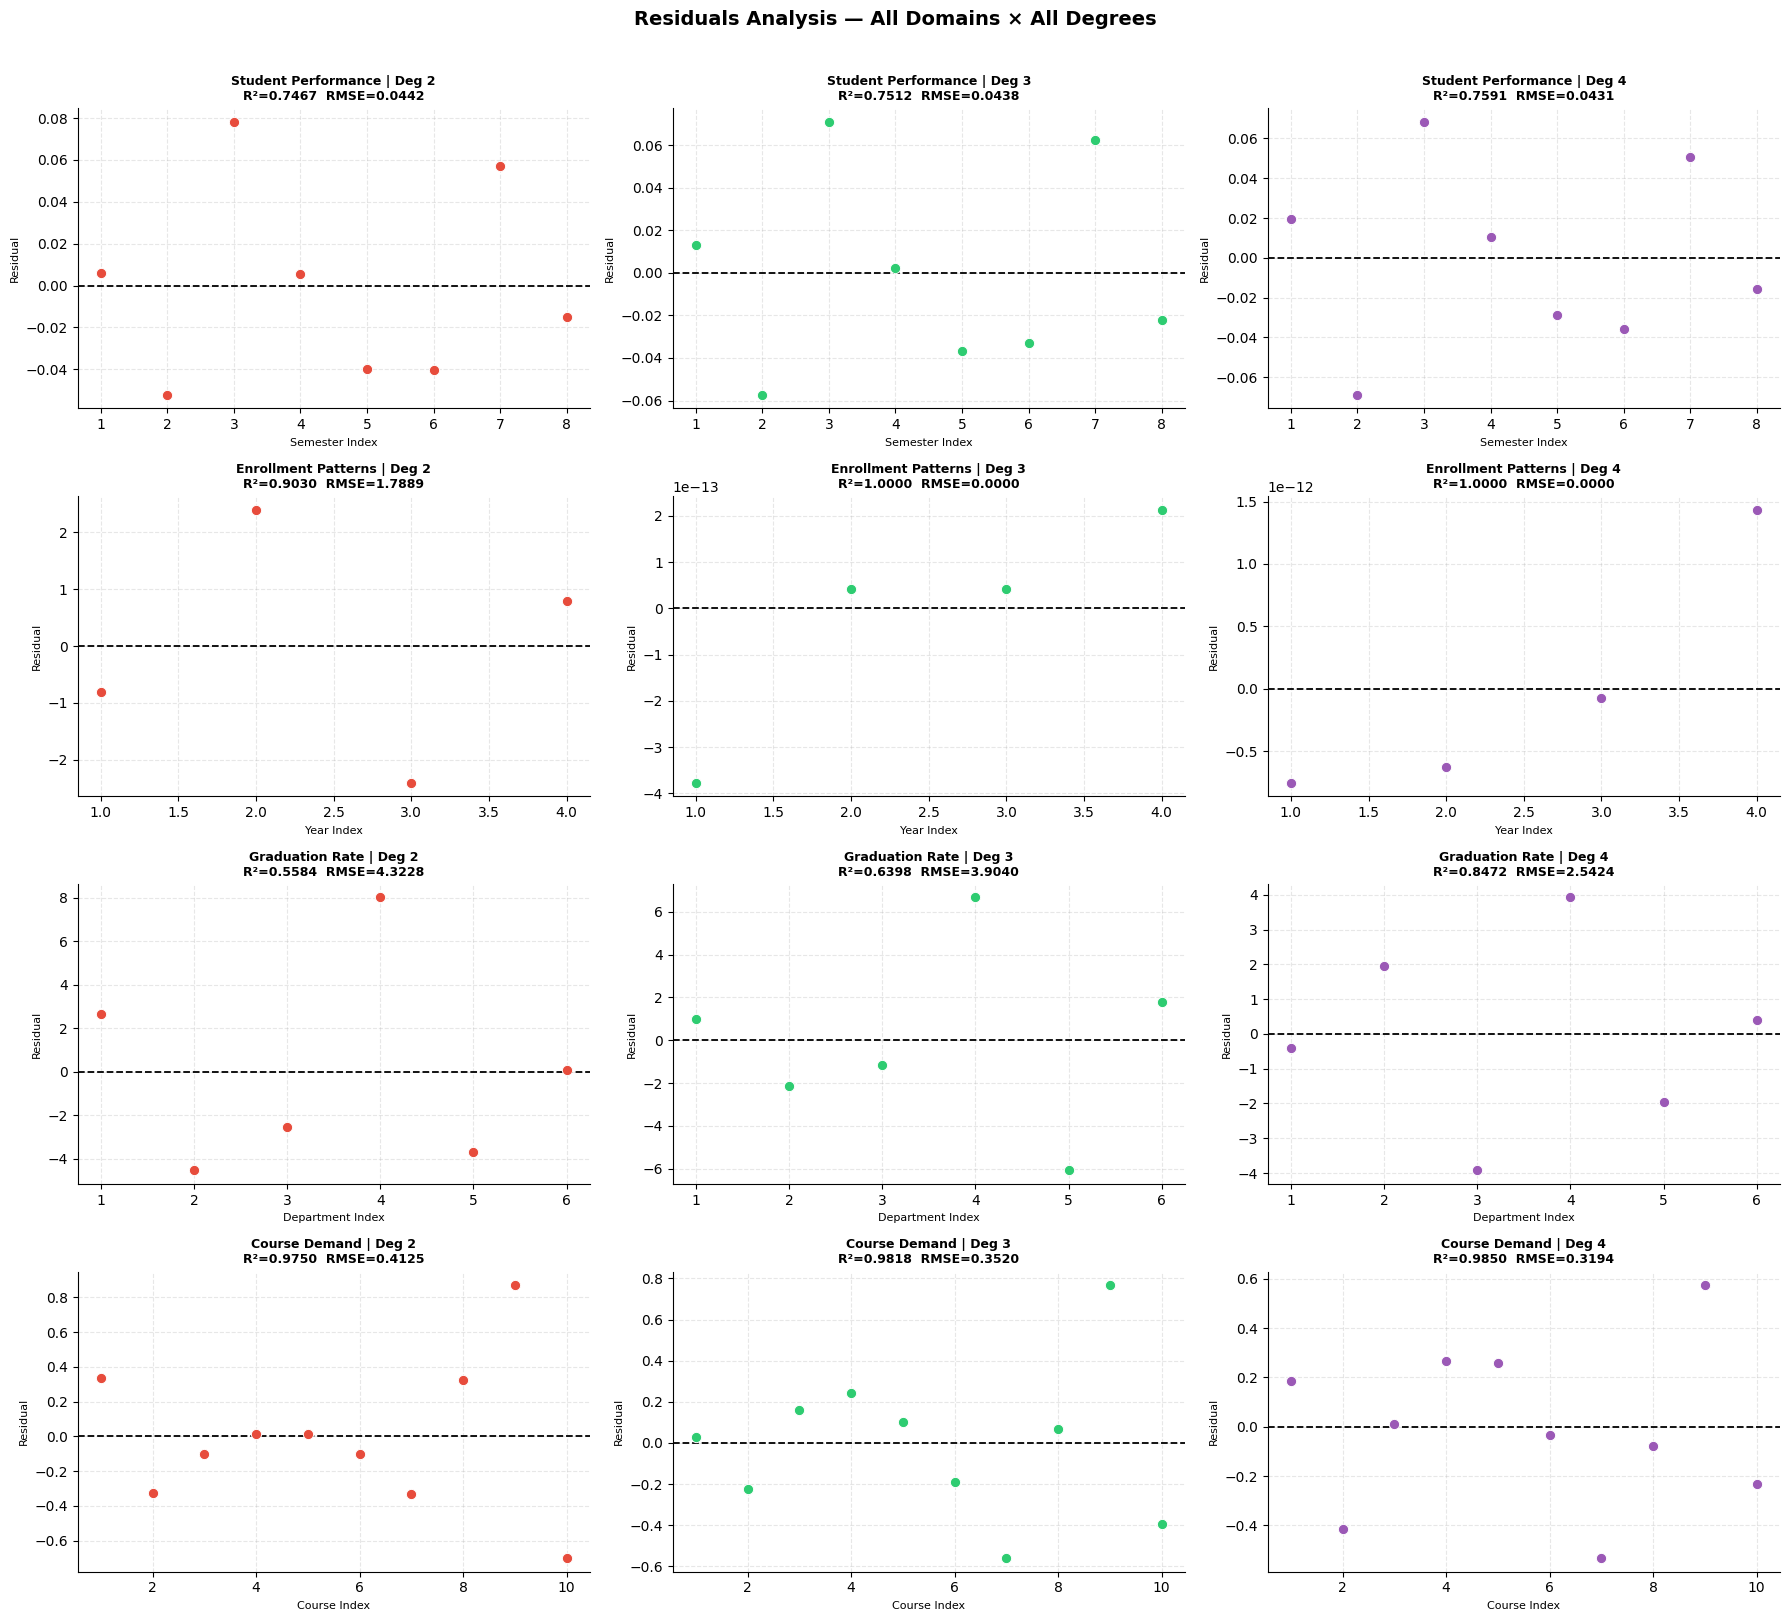

✔ Residuals chart saved as 'residuals_analysis.png'


In [8]:
domain_configs = [
    ("Student Performance", X1, y1, res1, "Semester Index"),
    ("Enrollment Patterns", X2, y2, res2, "Year Index"),
    ("Graduation Rate",     X3, y3, res3, "Department Index"),
    ("Course Demand",       X4, y4, res4, "Course Index"),
]
degree_colors = {2: "#e74c3c", 3: "#2ecc71", 4: "#9b59b6"}

fig2, axes2 = plt.subplots(4, 3, figsize=(18, 16))
fig2.suptitle("Residuals Analysis — All Domains × All Degrees",
              fontsize=14, fontweight="bold", y=1.01)

for row_i, (domain, X_flat, y, results, xlabel) in enumerate(domain_configs):
    for col_i, degree in enumerate([2, 3, 4]):
        ax = axes2[row_i, col_i]
        r2, rmse, y_pred, _ = results[degree]
        residuals = y - y_pred

        ax.axhline(0, color="black", linewidth=1.3, linestyle="--")
        ax.scatter(X_flat, residuals, color=degree_colors[degree],
                   s=55, edgecolors="white", linewidth=0.7, zorder=4)
        ax.set_title(f"{domain} | Deg {degree}\nR²={r2:.4f}  RMSE={rmse:.4f}",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel("Residual", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("residuals_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Residuals chart saved as 'residuals_analysis.png'")


## Cell 9 — Consolidated Results Table + CSV Export

In [9]:
degree_label = {2: "Quadratic", 3: "Cubic", 4: "Quartic"}

all_domains = {
    "Student Performance (GPA)":     res1,
    "Enrollment Patterns":           res2,
    "Graduation Rate (%)":           res3,
    "Course Demand (Registrations)": res4,
}

rows = []
for domain, res in all_domains.items():
    for d, (r2, rmse, _, _m) in res.items():
        rows.append({
            "Domain":     domain,
            "Degree":     d,
            "Model Type": degree_label[d],
            "R²":         round(r2, 4),
            "RMSE":       round(rmse, 4)
        })

df_results = pd.DataFrame(rows)
df_results.to_csv("polynomial_regression_results.csv", index=False)

print("✔ Results saved to 'polynomial_regression_results.csv'\n")
print(df_results.to_string(index=False))

# Highlight the best model per domain
print("\n── BEST MODEL PER DOMAIN (highest R²) ──")
best_rows = df_results.loc[df_results.groupby("Domain")["R²"].idxmax()]
print(best_rows.to_string(index=False))


✔ Results saved to 'polynomial_regression_results.csv'

                       Domain  Degree Model Type     R²   RMSE
    Student Performance (GPA)       2  Quadratic 0.7467 0.0442
    Student Performance (GPA)       3      Cubic 0.7512 0.0438
    Student Performance (GPA)       4    Quartic 0.7591 0.0431
          Enrollment Patterns       2  Quadratic 0.9030 1.7889
          Enrollment Patterns       3      Cubic 1.0000 0.0000
          Enrollment Patterns       4    Quartic 1.0000 0.0000
          Graduation Rate (%)       2  Quadratic 0.5584 4.3228
          Graduation Rate (%)       3      Cubic 0.6398 3.9040
          Graduation Rate (%)       4    Quartic 0.8472 2.5424
Course Demand (Registrations)       2  Quadratic 0.9750 0.4125
Course Demand (Registrations)       3      Cubic 0.9818 0.3520
Course Demand (Registrations)       4    Quartic 0.9850 0.3194

── BEST MODEL PER DOMAIN (highest R²) ──
                       Domain  Degree Model Type     R²   RMSE
Course Demand (Regis

## Cell 10 — Future Predictions (3 Steps Ahead)
Using the best model per domain to forecast.

In [10]:
print("=" * 60)
print("  FUTURE PREDICTIONS — BEST MODEL PER DOMAIN")
print("=" * 60)

future_configs = [
    ("Student Performance (GPA)",    X1, y1, res1, [9, 10],
     "Semester Index (9=Y5S1, 10=Y5S2 — postgrad)"),
    ("Enrollment Patterns",          X2, y2, res2, [5, 6],
     "Year Index  (5=next year, 6=year after)"),
    ("Graduation Rate (%)",          X3, y3, res3, [7],
     "Dept Index 7 (hypothetical new dept)"),
    ("Course Demand (Registrations)",X4, y4, res4, [11, 12],
     "Course Index 11 & 12 (new courses)"),
]

for domain, X_flat, y, results, future_X, label in future_configs:
    best_d = max(results, key=lambda d: results[d][0])
    r2     = results[best_d][0]
    model  = results[best_d][3]

    future_arr   = np.array(future_X).reshape(-1, 1).astype(float)
    future_preds = model.predict(future_arr)

    print(f"\n  {domain}")
    print(f"  Best model: Degree {best_d} ({degree_label[best_d]})  R²={r2:.4f}")
    print(f"  {label}")
    for fx, fp in zip(future_X, future_preds):
        print(f"    Index {fx:>3}  →  Predicted = {fp:.3f}")


  FUTURE PREDICTIONS — BEST MODEL PER DOMAIN

  Student Performance (GPA)
  Best model: Degree 4 (Quartic)  R²=0.7591
  Semester Index (9=Y5S1, 10=Y5S2 — postgrad)
    Index   9  →  Predicted = 3.294
    Index  10  →  Predicted = 3.157

  Enrollment Patterns
  Best model: Degree 3 (Cubic)  R²=1.0000
  Year Index  (5=next year, 6=year after)
    Index   5  →  Predicted = 85.000
    Index   6  →  Predicted = 151.000

  Graduation Rate (%)
  Best model: Degree 4 (Quartic)  R²=0.8472
  Dept Index 7 (hypothetical new dept)
    Index   7  →  Predicted = 71.787

  Course Demand (Registrations)
  Best model: Degree 4 (Quartic)  R²=0.9850
  Course Index 11 & 12 (new courses)
    Index  11  →  Predicted = 14.083
    Index  12  →  Predicted = 10.462


## Cell 11 — How to Interpret the Results

### R² (R-squared)
| Value | Meaning |
|---|---|
| 1.00 | Perfect — model explains ALL variance |
| ≥ 0.90 | Very good |
| 0.70–0.89 | Moderate |
| < 0.50 | Weak |
| < 0.00 | Worse than just predicting the mean |

### RMSE
- Same units as the target variable (e.g., GPA points, number of students)
- Lower = better; only compare RMSE **within** the same domain

### Which degree to choose?
| Degree | Shape | Use when… |
|---|---|---|
| 2 — Quadratic | U-shape / arc | One simple peak or trough |
| 3 — Cubic | S-shape | One trend reversal |
| 4 — Quartic | Two bends | Two reversals / complex pattern |

> ⚠️ Higher degree ≠ always better. Degree 4 may **overfit** on small datasets — it traces the noise perfectly during training but fails on new data. Prefer the **lowest degree with acceptable R²**.

### Output files generated
| File | Contents |
|---|---|
| `polynomial_regression_comparison.png` | 4-domain curves comparison |
| `residuals_analysis.png` | Residuals for all 12 models |
| `polynomial_regression_results.csv` | Full R² / RMSE table |
